# FreeVIZ and SPCA comparison

In this notebook, we compare resulting vizualizations of FreeViz and SPCA for classification on three datasets.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import torch
import matplotlib.pyplot as plt
import numpy as np

import importlib
import utils
importlib.reload(utils)

from models import Freeviz
from models.spca_classification import SPCA_Classification
from utils import load_zoo_data, load_car_data, scale_features, plot_projection

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/home/jasa/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


# The ZOO dataset

#### Data preparation

In [3]:
E_raw, C, names, feature_names, class_names = load_zoo_data(device)
E = scale_features(E_raw)

#### Train FreeVIZ

In [4]:
freeviz = Freeviz(E.shape[1]).to(device)
freeviz.train(E, C)

P = freeviz(E)
A = freeviz.A
P_np = P.detach().cpu().numpy()
C_np = C.detach().cpu().numpy()
A_np = A.detach().cpu().numpy()

step: 1 loss: 18686.888671875
step: 2 loss: 18908.298828125
step: 3 loss: 20747.65625
step: 4 loss: 19673.408203125
step: 5 loss: 12314.7578125
step: 6 loss: 11629.3037109375
step: 7 loss: 12073.1474609375
step: 8 loss: 12357.669921875
step: 9 loss: 12604.470703125
step: 10 loss: 12704.3095703125
step: 11 loss: 12857.6171875


#### Train SPCA Classification

In [5]:
model = SPCA_Classification(input_dim=E.shape[1], latent_dim=2, num_classes=len(class_names), lr=0.05).to(device)
E_centered = E - E.mean(dim=0)
lam = 0.01
steps = 1000
model.train(E_centered, C, lam=lam, steps=steps, classifier_epochs=50)

L = model.L.detach().clone()
L = L - L.mean(dim=0, keepdim=True)
loading_norms = torch.norm(L, dim=1)
L = L / loading_norms.max()

Z = E_centered @ L
z_max = torch.abs(Z).max()
Z = Z / z_max

Z_np = Z.cpu().numpy()
C_np_spca = C.cpu().numpy()
L_np = L.cpu().numpy()

Step 0: loss = 3.1413, classifier loss = 1.8430


Step 10: loss = 2.4828, classifier loss = 1.1800


Step 20: loss = 2.2175, classifier loss = 0.9123


Step 30: loss = 2.0930, classifier loss = 0.7868


Step 40: loss = 2.0177, classifier loss = 0.7105


...

Step 790: loss = 1.5744, classifier loss = 0.2176
Step 800: loss = 1.5737, classifier loss = 0.2167
Step 810: loss = 1.5730, classifier loss = 0.2159
Step 820: loss = 1.5722, classifier loss = 0.2150
Step 830: loss = 1.5715, classifier loss = 0.2142


Step 840: loss = 1.5708, classifier loss = 0.2133
Step 850: loss = 1.5702, classifier loss = 0.2125
Step 860: loss = 1.5695, classifier loss = 0.2118
Step 870: loss = 1.5688, classifier loss = 0.2108


Step 880: loss = 1.5681, classifier loss = 0.2099
Step 890: loss = 1.5674, classifier loss = 0.2092
Step 900: loss = 1.5668, classifier loss = 0.2084
Step 910: loss = 1.5661, classifier loss = 0.2076


Step 920: loss = 1.5655, classifier loss = 0.2068
Step 930: loss = 1.5648, classifier loss = 0.2059
Step 940: loss = 1.5642, classifier loss = 0.2052
Step 950: loss = 1.5635, classifier loss = 0.2043
Step 960: loss = 1.5629, classifier loss = 0.2036


Step 970: loss = 1.5623, classifier loss = 0.2027
Step 980: loss = 1.5616, classifier loss = 0.2021
Step 990: loss = 1.5610, classifier loss = 0.2014


### Side-by-side comparison

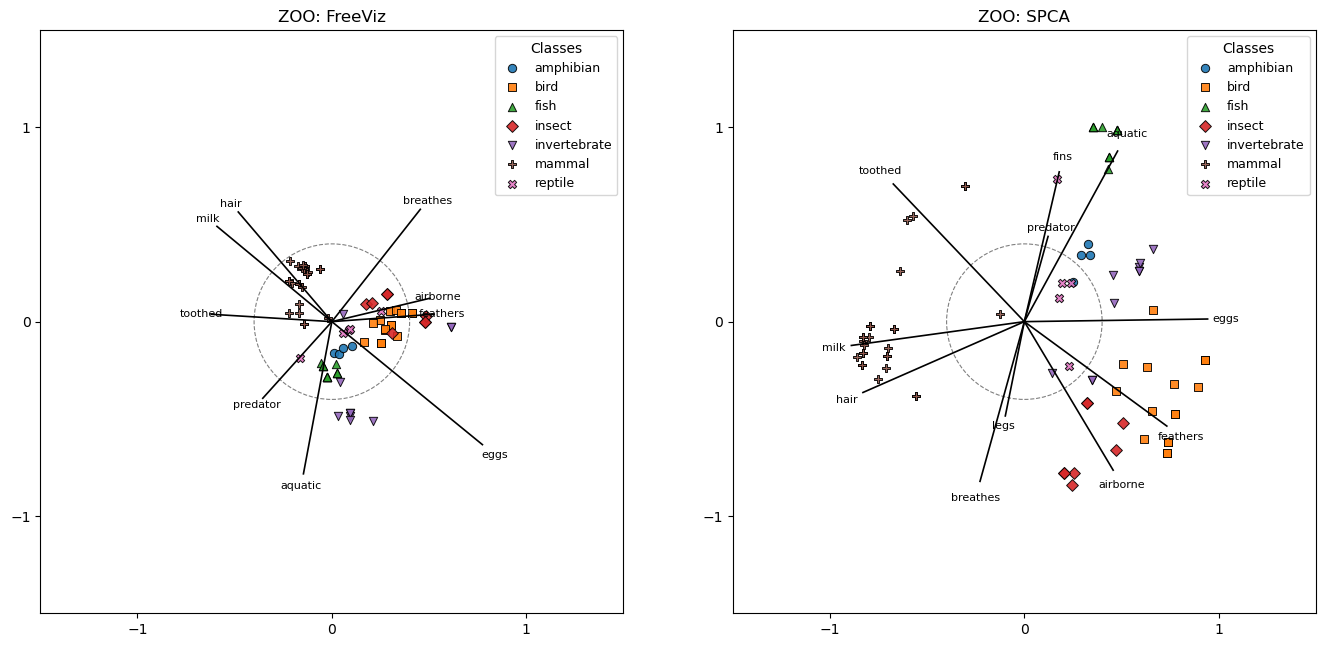

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

plot_projection(
    P_np, A_np, feature_names, C_np, class_names,
    title='ZOO: FreeViz', ax=ax1, text_scale=1.08
)

plot_projection(
    Z_np, L_np, feature_names, C_np_spca, class_names,
    title='ZOO: SPCA', ax=ax2, text_scale=1.1
)

plt.tight_layout()
plt.show()

# The CAR dataset

#### Data preparation

In [7]:
E_car, C_car, names_car, feature_names_car, class_names_car = load_car_data(device)
E_car = scale_features(E_car)

#### Train FreeVIZ

In [8]:
freeviz_car = Freeviz(E_car.shape[1]).to(device)
freeviz_car.train(E_car, C_car)

P_car = freeviz_car(E_car)
A_car = freeviz_car.A
P_car_np = P_car.detach().cpu().numpy()
C_car_np = C_car.detach().cpu().numpy()
A_car_np = A_car.detach().cpu().numpy()

step: 1 loss: 8540379.0


step: 2 loss: 928786496.0


step: 3 loss: 2537256.75


step: 4 loss: 2561352.25


step: 5 loss: 2561351.5


step: 6 loss: 2561350.75


step: 7 loss: 2561350.25


step: 8 loss: 2561350.0


#### Train SPCA Classification

In [9]:
model_car = SPCA_Classification(input_dim=E_car.shape[1], latent_dim=2, num_classes=len(class_names_car), lr=0.05).to(device)
E_car_centered = E_car - E_car.mean(dim=0)
model_car.train(E_car_centered, C_car, lam=0.01, steps=1000, classifier_epochs=50)

L_car = model_car.L.detach().clone()
L_car = L_car - L_car.mean(dim=0, keepdim=True)
loading_norms_car = torch.norm(L_car, dim=1)
L_car = L_car / loading_norms_car.max()

Z_car = E_car_centered @ L_car
z_max_car = torch.abs(Z_car).max()
Z_car = Z_car / z_max_car

Z_car_np = Z_car.cpu().numpy()
C_car_np_spca = C_car.cpu().numpy()
L_car_np = L_car.cpu().numpy()

Step 0: loss = 63.2484, classifier loss = 1.3299


Step 10: loss = 62.8126, classifier loss = 0.8900


Step 20: loss = 62.6128, classifier loss = 0.6885


Step 30: loss = 62.5100, classifier loss = 0.5857


Step 40: loss = 62.4580, classifier loss = 0.5327


...

Step 860: loss = 62.3032, classifier loss = 0.3483
Step 870: loss = 62.3023, classifier loss = 0.3465
Step 880: loss = 62.3014, classifier loss = 0.3455


Step 890: loss = 62.3004, classifier loss = 0.3442
Step 900: loss = 62.2996, classifier loss = 0.3434


Step 910: loss = 62.2987, classifier loss = 0.3416
Step 920: loss = 62.2977, classifier loss = 0.3407
Step 930: loss = 62.2968, classifier loss = 0.3391


Step 940: loss = 62.2959, classifier loss = 0.3382
Step 950: loss = 62.2950, classifier loss = 0.3368
Step 960: loss = 62.2941, classifier loss = 0.3357


Step 970: loss = 62.2931, classifier loss = 0.3342
Step 980: loss = 62.2921, classifier loss = 0.3330
Step 990: loss = 62.2911, classifier loss = 0.3318


### Side-by-side comparison

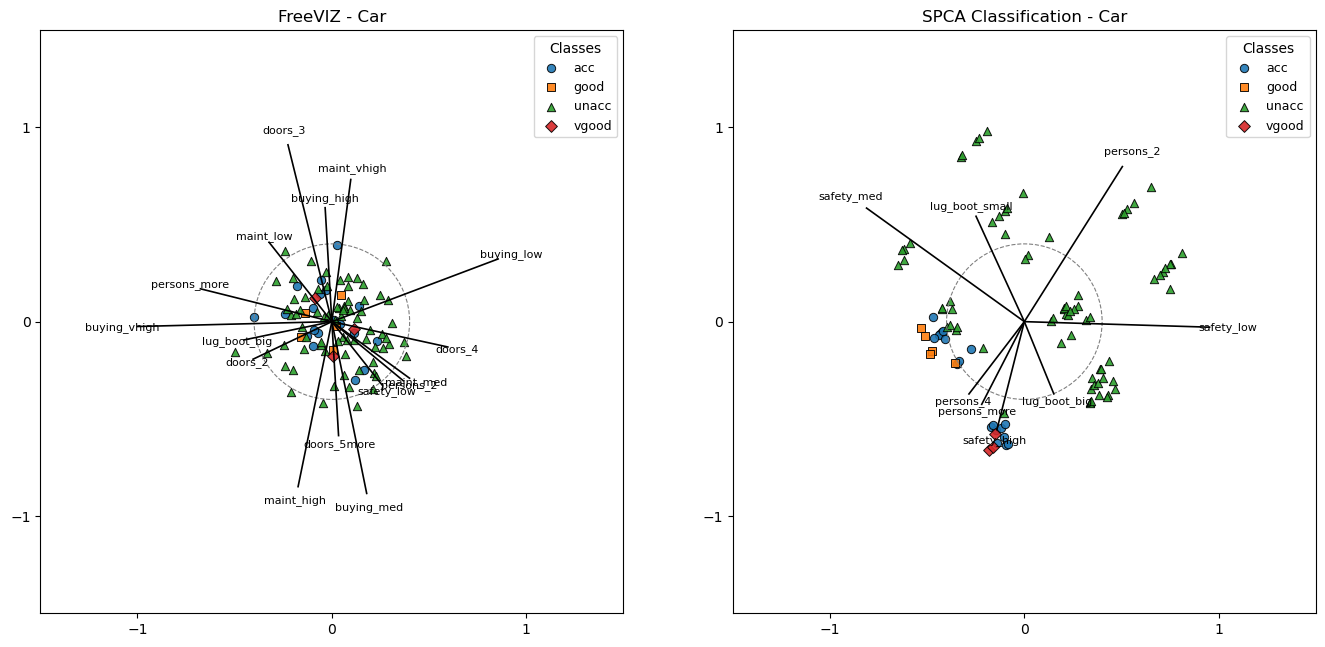

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

plot_projection(
    points=P_car_np, vectors=A_car_np, feature_names=feature_names_car,
    class_codes=C_car_np, class_names=class_names_car,
    title='FreeVIZ - Car', ax=ax1, text_scale=1.08
)

plot_projection(
    points=Z_car_np, vectors=L_car_np, feature_names=feature_names_car,
    class_codes=C_car_np_spca, class_names=class_names_car,
    title='SPCA Classification - Car', ax=ax2, text_scale=1.1
)

plt.tight_layout()
plt.show()